<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [ ]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

#### 2. Connect to the Database


**Install the needed libraries**


In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import requests

# URL completa del archivo .sqlite suministrado por IBM
db_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite"

# Descargar la base de datos
response = requests.get(db_url)
response.raise_for_status()

with open("survey-data.sqlite", "wb") as file:
    file.write(response.content)

# Conectar al archivo local
conn = sqlite3.connect("survey-data.sqlite")

print("Database connection successful.")

Database connection successful.


In [3]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

display(tables)

,name
0,main


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [4]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [ ]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


Use a box plot to analyze the distribution and outliers in total compensation.


In [10]:
# Retrieve CompTotal from the database
QUERY = """
SELECT CompTotal
FROM main
"""

comp_df = pd.read_sql_query(QUERY, conn)

# Convert to numeric
comp_df["CompTotal"] = pd.to_numeric(
    comp_df["CompTotal"],
    errors="coerce"
)

# Validate the data
print("Total records:", len(comp_df))
print("Valid values:", comp_df["CompTotal"].notna().sum())
print("Missing values:", comp_df["CompTotal"].isna().sum())

print("\nSummary statistics:")
print(comp_df["CompTotal"].describe())

Total records: 65437
Valid values: 33740
Missing values: 31697

Summary statistics:
count     3.374000e+04
mean     2.963841e+145
std      5.444117e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.500000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64


In [11]:
Q1 = comp_df["CompTotal"].quantile(0.25)
Q3 = comp_df["CompTotal"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = comp_df[
    (comp_df["CompTotal"] < lower_bound) |
    (comp_df["CompTotal"] > upper_bound)
]

print(f"Q1: {Q1:,.2f}")
print(f"Q3: {Q3:,.2f}")
print(f"IQR: {IQR:,.2f}")
print(f"Lower bound: {lower_bound:,.2f}")
print(f"Upper bound: {upper_bound:,.2f}")
print("Number of potential outliers:", len(outliers))

Q1: 60,000.00
Q3: 250,000.00
IQR: 190,000.00
Lower bound: -225,000.00
Upper bound: 535,000.00
Number of potential outliers: 5876


95th percentile: $3,600,000.00


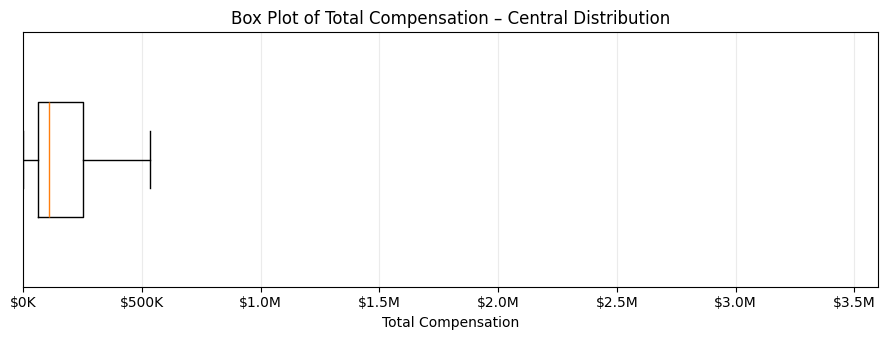

In [15]:
from matplotlib.ticker import FuncFormatter

valid_comp = comp_df["CompTotal"].dropna()

# Visual limit only
visual_limit = valid_comp.quantile(0.95)

print(f"95th percentile: ${visual_limit:,.2f}")

plt.figure(figsize=(9, 3.5))

plt.boxplot(
    valid_comp,
    vert=False,
    widths=0.45,
    showfliers=False
)

# Zoom only the chart
plt.xlim(0, visual_limit)

# Monetary formatting
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M"
                  if x >= 1_000_000
                  else f"${x/1_000:.0f}K")
)

plt.title("Box Plot of Total Compensation – Central Distribution")
plt.xlabel("Total Compensation")
plt.yticks([])

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


Valid age values: 65115
Median age: 29.5
Q1: 21.0
Q3: 39.5


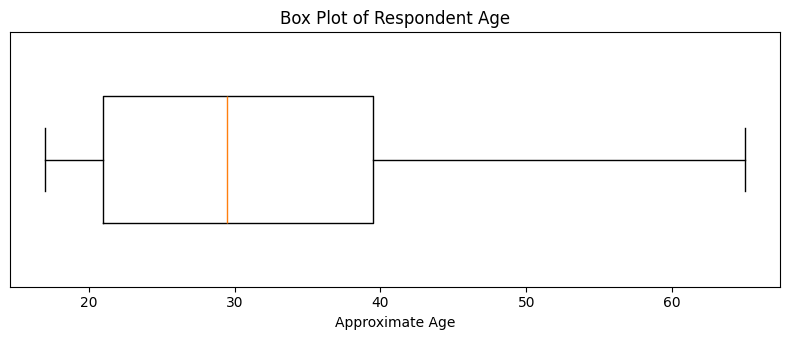

In [16]:
# Retrieve Age data
QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""

age_df = pd.read_sql_query(QUERY, conn)

# Map age ranges to approximate numeric values
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65,
    "Prefer not to say": None
}

age_df["AgeNumeric"] = age_df["Age"].map(age_mapping)

# Keep valid numeric ages
age_values = age_df["AgeNumeric"].dropna()

print("Valid age values:", len(age_values))
print("Median age:", age_values.median())
print("Q1:", age_values.quantile(0.25))
print("Q3:", age_values.quantile(0.75))

# Box plot
plt.figure(figsize=(8, 3.5))

plt.boxplot(
    age_values,
    vert=False,
    widths=0.5
)

plt.title("Box Plot of Respondent Age")
plt.xlabel("Approximate Age")
plt.yticks([])

plt.tight_layout()
plt.show()


In [17]:
# Validate potential Age outliers using the IQR method

Q1 = age_values.quantile(0.25)
Q3 = age_values.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

age_outliers = age_values[
    (age_values < lower_bound) |
    (age_values > upper_bound)
]

print(f"Q1: {Q1:.2f}")
print(f"Median: {age_values.median():.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

print(f"\nLower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

print(f"\nMinimum age value: {age_values.min():.2f}")
print(f"Maximum age value: {age_values.max():.2f}")

print("Number of potential outliers:", len(age_outliers))

if len(age_outliers) == 0:
    print("No Age values are classified as outliers by the IQR rule.")
else:
    print("\nPotential outliers:")
    print(age_outliers.value_counts().sort_index())

Q1: 21.00
Median: 29.50
Q3: 39.50
IQR: 18.50

Lower bound: -6.75
Upper bound: 67.25

Minimum age value: 17.00
Maximum age value: 65.00
Number of potential outliers: 0
No Age values are classified as outliers by the IQR rule.


### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


95th percentile for visualization: 3,600,000.00


,count,median
Age,,
Under 18 years old,90,17000.0
18-24 years old,4636,63000.0
25-34 years old,14657,101000.0
35-44 years old,9352,120000.0
45-54 years old,3516,130000.0
55-64 years old,1279,135000.0
65 years or older,196,128642.5


C:\Users\Gedec\AppData\Local\Temp\ipykernel_25048\1615369557.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


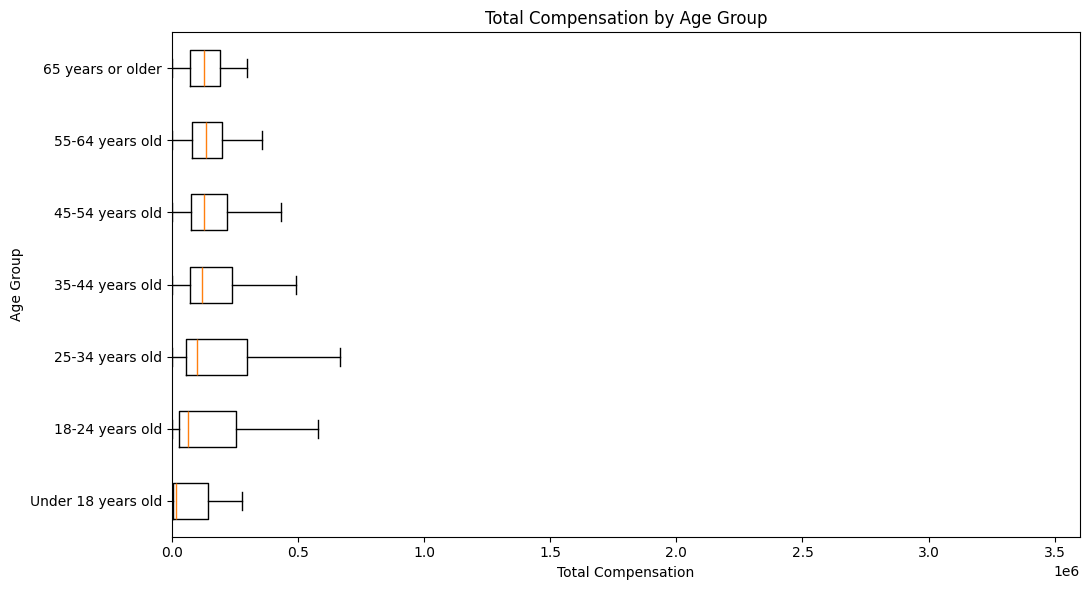

In [18]:
# Retrieve data
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL
  AND CompTotal IS NOT NULL
"""

age_comp = pd.read_sql_query(QUERY, conn)

age_comp["CompTotal"] = pd.to_numeric(
    age_comp["CompTotal"],
    errors="coerce"
)

age_comp = age_comp.dropna(subset=["Age", "CompTotal"])

# Remove "Prefer not to say" only from this comparison
age_comp = age_comp[
    age_comp["Age"] != "Prefer not to say"
]

# Logical age order
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

# Prepare one compensation array per age group
box_data = [
    age_comp.loc[
        age_comp["Age"] == age, "CompTotal"
    ].values
    for age in age_order
]

# Use 95th percentile only as visual zoom
visual_limit = age_comp["CompTotal"].quantile(0.95)

print(f"95th percentile for visualization: {visual_limit:,.2f}")

# Median by age group
display(
    age_comp.groupby("Age")["CompTotal"]
    .agg(["count", "median"])
    .reindex(age_order)
)

plt.figure(figsize=(11, 6))

plt.boxplot(
    box_data,
    labels=age_order,
    vert=False,
    showfliers=False
)

plt.xlim(0, visual_limit)

plt.title("Total Compensation by Age Group")
plt.xlabel("Total Compensation")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [19]:
QUERY = """
SELECT JobSatPoints_6, CompTotal
FROM main
WHERE JobSatPoints_6 IS NOT NULL
  AND CompTotal IS NOT NULL
"""

sat_comp = pd.read_sql_query(QUERY, conn)

sat_comp["JobSatPoints_6"] = pd.to_numeric(
    sat_comp["JobSatPoints_6"],
    errors="coerce"
)

sat_comp["CompTotal"] = pd.to_numeric(
    sat_comp["CompTotal"],
    errors="coerce"
)

sat_comp = sat_comp.dropna(
    subset=["JobSatPoints_6", "CompTotal"]
)

print("JobSatPoints_6 summary:")
display(sat_comp["JobSatPoints_6"].describe())

print("\nUnique values:")
print(sorted(sat_comp["JobSatPoints_6"].unique()))

JobSatPoints_6 summary:


count    22478.000000
mean        24.940168
std         26.358629
min          0.000000
25%          5.000000
50%         20.000000
75%         30.000000
max        100.000000
Name: JobSatPoints_6, dtype: float64


Unique values:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(12.5), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(17.5), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(33.3), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0), np.float64(52.0), np.float64(54.0), np.

,count,median
SatisfactionGroup,,
Very Low,13897,110000.0
Low,4586,113000.0
Medium,1517,115000.0
High,1126,115000.0
Very High,1352,125500.0


C:\Users\Gedec\AppData\Local\Temp\ipykernel_25048\952337954.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


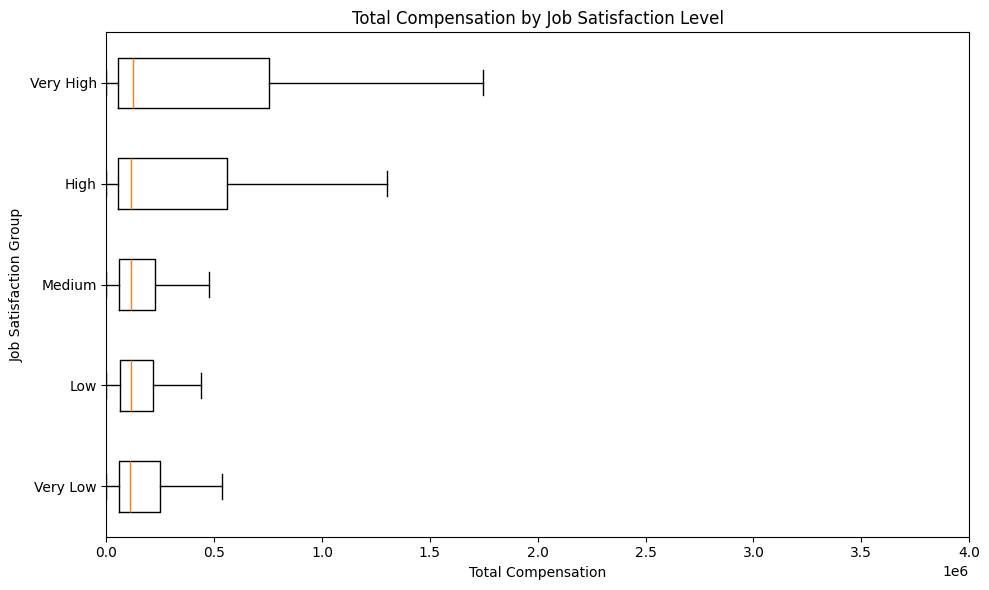

In [20]:
# Create satisfaction-point groups
sat_comp["SatisfactionGroup"] = pd.cut(
    sat_comp["JobSatPoints_6"],
    bins=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

# Summary
display(
    sat_comp.groupby(
        "SatisfactionGroup",
        observed=True
    )["CompTotal"]
    .agg(["count", "median"])
)

groups = [
    "Very Low",
    "Low",
    "Medium",
    "High",
    "Very High"
]

box_data = [
    sat_comp.loc[
        sat_comp["SatisfactionGroup"] == group,
        "CompTotal"
    ].values
    for group in groups
]

visual_limit = sat_comp["CompTotal"].quantile(0.95)

plt.figure(figsize=(10, 6))

plt.boxplot(
    box_data,
    labels=groups,
    vert=False,
    showfliers=False
)

plt.xlim(0, visual_limit)

plt.title("Total Compensation by Job Satisfaction Level")
plt.xlabel("Total Compensation")
plt.ylabel("Job Satisfaction Group")

plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


Top 5 Developer Types:
- Developer, full-stack
- Developer, back-end
- Student
- Developer, front-end
- Developer, desktop or enterprise applications


,Count,Median,Q1,Q3
DevType,,,,
"Developer, full-stack",8290,63316.0,30731.00,101770.0
"Developer, back-end",4738,67132.0,34484.25,110000.0
Student,141,16000.0,6444.00,30933.0
"Developer, front-end",1412,48774.5,18381.75,85925.0
"Developer, desktop or enterprise applications",1061,63600.0,37436.00,102822.0


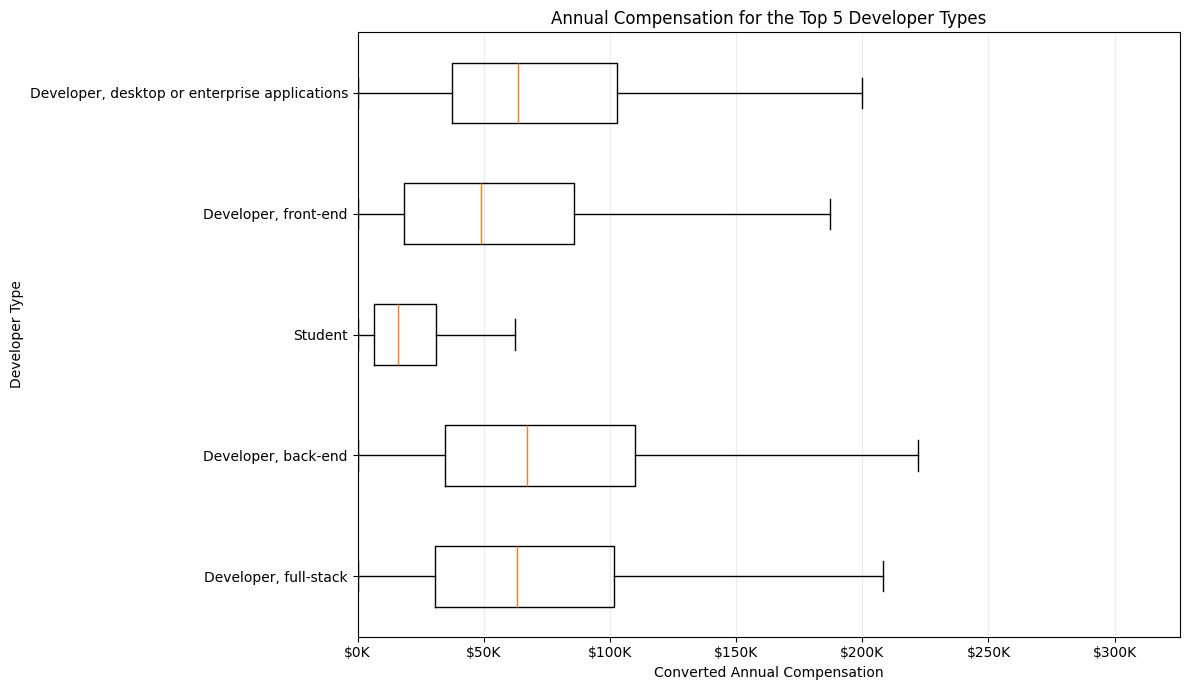

In [21]:
# Task 3.1 - Box Plot of ConvertedCompYearly for Top 5 Developer Types

QUERY = """
SELECT ResponseId, DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL
"""

dev_df = pd.read_sql_query(QUERY, conn)

# Convert compensation to numeric
dev_df["ConvertedCompYearly"] = pd.to_numeric(
    dev_df["ConvertedCompYearly"],
    errors="coerce"
)

# Split multiple developer roles
dev_long = dev_df.copy()
dev_long["DevType"] = dev_long["DevType"].str.split(";")
dev_long = dev_long.explode("DevType", ignore_index=True)
dev_long["DevType"] = dev_long["DevType"].str.strip()

# Identify Top 5 developer roles by frequency
top5_roles = (
    dev_long["DevType"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

print("Top 5 Developer Types:")
for role in top5_roles:
    print("-", role)

# Keep top 5 roles with valid compensation
plot_dev = dev_long[
    dev_long["DevType"].isin(top5_roles)
].dropna(subset=["ConvertedCompYearly"])

# Summary statistics
dev_summary = (
    plot_dev.groupby("DevType")["ConvertedCompYearly"]
    .agg(
        Count="count",
        Median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .reindex(top5_roles)
)

display(dev_summary.round(2))

# Prepare boxplot data
box_data = [
    plot_dev.loc[
        plot_dev["DevType"] == role,
        "ConvertedCompYearly"
    ].values
    for role in top5_roles
]

# Visual zoom only
visual_limit = plot_dev["ConvertedCompYearly"].quantile(0.99)

plt.figure(figsize=(12, 7))

plt.boxplot(
    box_data,
    tick_labels=top5_roles,
    vert=False,
    showfliers=False
)

plt.xlim(0, visual_limit)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos:
        f"${x/1_000_000:.1f}M"
        if x >= 1_000_000
        else f"${x/1_000:.0f}K"
    )
)

plt.title("Annual Compensation for the Top 5 Developer Types")
plt.xlabel("Converted Annual Compensation")
plt.ylabel("Developer Type")

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


Top 5 Countries:
- United States of America
- Germany
- India
- United Kingdom of Great Britain and Northern Ireland
- Ukraine


,Count,Median,Q1,Q3
Country,,,,
United States of America,7042,147000.0,104000.0,200000.0
Germany,3004,69000.0,51000.0,87000.0
India,1551,1300000.0,510000.0,2675000.0
United Kingdom of Great Britain and Northern Ireland,2008,67000.0,46000.0,95000.0
Ukraine,1610,66000.0,30000.0,700000.0


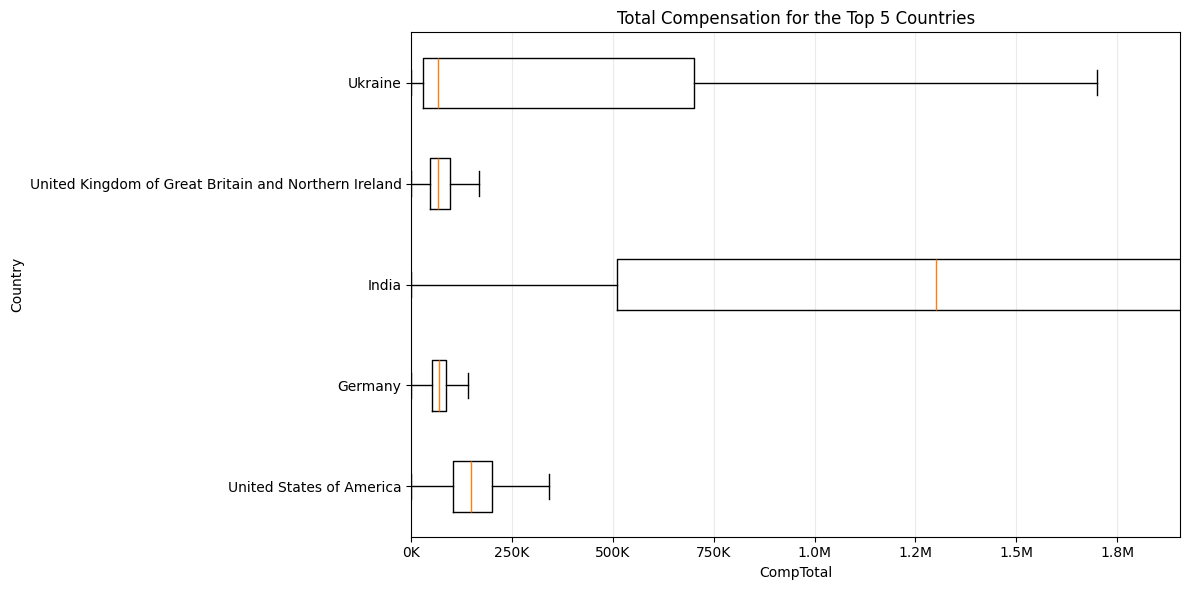

In [23]:
# Task 3.2 - Box Plot of CompTotal for Top 5 Countries

QUERY = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL
"""

country_df = pd.read_sql_query(QUERY, conn)

country_df["CompTotal"] = pd.to_numeric(
    country_df["CompTotal"],
    errors="coerce"
)

# Top 5 countries by number of respondents
top5_countries = (
    country_df["Country"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

print("Top 5 Countries:")
for country in top5_countries:
    print("-", country)

# Keep top countries and valid compensation
country_plot = country_df[
    country_df["Country"].isin(top5_countries)
].dropna(subset=["CompTotal"])

# Summary
country_summary = (
    country_plot.groupby("Country")["CompTotal"]
    .agg(
        Count="count",
        Median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .reindex(top5_countries)
)

display(country_summary.round(2))

box_data = [
    country_plot.loc[
        country_plot["Country"] == country,
        "CompTotal"
    ].values
    for country in top5_countries
]

# Visual zoom only
visual_limit = country_plot["CompTotal"].quantile(0.95)

plt.figure(figsize=(12, 6))

plt.boxplot(
    box_data,
    tick_labels=top5_countries,
    vert=False,
    showfliers=False
)

plt.xlim(0, visual_limit)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos:
        f"{x/1_000_000:.1f}M"
        if x >= 1_000_000
        else f"{x/1_000:.0f}K"
    )
)

plt.title("Total Compensation for the Top 5 Countries")
plt.xlabel("CompTotal")
plt.ylabel("Country")

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [24]:
# Task 4.1 - CompTotal across Employment Types

QUERY = """
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL
  AND CompTotal IS NOT NULL
"""

employment_comp = pd.read_sql_query(QUERY, conn)

employment_comp["CompTotal"] = pd.to_numeric(
    employment_comp["CompTotal"],
    errors="coerce"
)

# Split multiple employment selections
employment_comp["Employment"] = (
    employment_comp["Employment"]
    .str.split(";")
)

employment_comp = employment_comp.explode(
    "Employment",
    ignore_index=True
)

employment_comp["Employment"] = (
    employment_comp["Employment"]
    .str.strip()
)

employment_comp = employment_comp.dropna(
    subset=["Employment", "CompTotal"]
)

# Order employment types by frequency
employment_order = (
    employment_comp["Employment"]
    .value_counts()
    .index
    .tolist()
)

# Summary statistics
employment_summary = (
    employment_comp
    .groupby("Employment")["CompTotal"]
    .agg(
        Count="count",
        Median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .reindex(employment_order)
)

display(employment_summary.round(2))

,Count,Median,Q1,Q3
Employment,,,,
"Employed, full-time",29231,113000.0,60000.0,256974.0
"Independent contractor, freelancer, or self-employed",5816,120000.0,60000.0,300000.0
"Employed, part-time",2005,50400.0,21600.0,113400.0
"Student, full-time",1191,36000.0,14400.0,100000.0
"Student, part-time",1028,60000.0,26000.0,140000.0
"Not employed, but looking for work",237,85000.0,24000.0,384000.0
Retired,40,60000.0,15000.0,240000.0
"Not employed, and not looking for work",40,127500.0,2257.5,615000.0


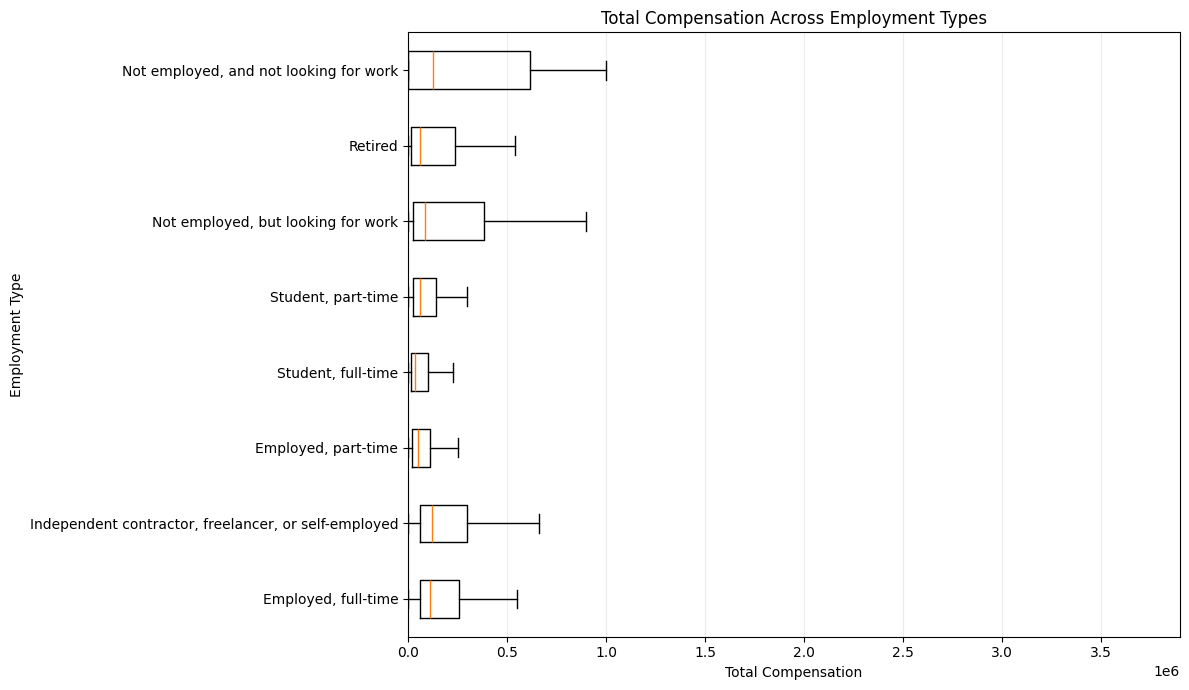

In [26]:
box_data = [
    employment_comp.loc[
        employment_comp["Employment"] == employment,
        "CompTotal"
    ].values
    for employment in employment_order
]

# Visual zoom only
visual_limit = employment_comp["CompTotal"].quantile(0.95)

plt.figure(figsize=(12, 7))

plt.boxplot(
    box_data,
    tick_labels=employment_order,
    vert=False,
    showfliers=False
)

plt.xlim(0, visual_limit)

plt.title("Total Compensation Across Employment Types")
plt.xlabel("Total Compensation")
plt.ylabel("Employment Type")

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


In [ ]:
# Task 4.2 - YearsCodePro by JobSatPoints_6

QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
  AND JobSatPoints_6 IS NOT NULL
"""

experience_sat = pd.read_sql_query(QUERY, conn)

# Convert YearsCodePro
experience_sat["YearsCodeProNumeric"] = (
    experience_sat["YearsCodePro"]
    .replace({
        "Less than 1 year": 0.5,
        "More than 50 years": 51
    })
)

experience_sat["YearsCodeProNumeric"] = pd.to_numeric(
    experience_sat["YearsCodeProNumeric"],
    errors="coerce"
)

experience_sat["JobSatPoints_6"] = pd.to_numeric(
    experience_sat["JobSatPoints_6"],
    errors="coerce"
)

experience_sat = experience_sat.dropna(
    subset=["YearsCodeProNumeric", "JobSatPoints_6"]
)

print("JobSatPoints_6 summary:")
display(experience_sat["JobSatPoints_6"].describe())



JobSatPoints_6 summary:


count    28619.000000
mean        24.603731
std         27.088177
min          0.000000
25%          0.000000
50%         20.000000
75%         30.000000
max        100.000000
Name: JobSatPoints_6, dtype: float64

In [29]:
# Create quantile-based satisfaction groups
experience_sat["SatisfactionLevel"] = pd.qcut(
    experience_sat["JobSatPoints_6"],
    q=5,
    duplicates="drop"
)

# Check the actual groups created
print("Satisfaction groups created:")
print(
    experience_sat["SatisfactionLevel"]
    .value_counts()
    .sort_index()
)

# Summary of YearsCodePro by satisfaction group
sat_summary = (
    experience_sat
    .groupby(
        "SatisfactionLevel",
        observed=True
    )["YearsCodeProNumeric"]
    .agg(
        Count="count",
        Median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
)

display(sat_summary.round(2))

Satisfaction groups created:
SatisfactionLevel
(-0.001, 10.0]    11974
(10.0, 20.0]       6086
(20.0, 40.0]       5367
(40.0, 100.0]      5192
Name: count, dtype: int64


,Count,Median,Q1,Q3
SatisfactionLevel,,,,
"(-0.001, 10.0]",11974,7.0,3.0,14.0
"(10.0, 20.0]",6086,9.0,5.0,16.0
"(20.0, 40.0]",5367,9.0,5.0,16.0
"(40.0, 100.0]",5192,7.0,3.0,12.0


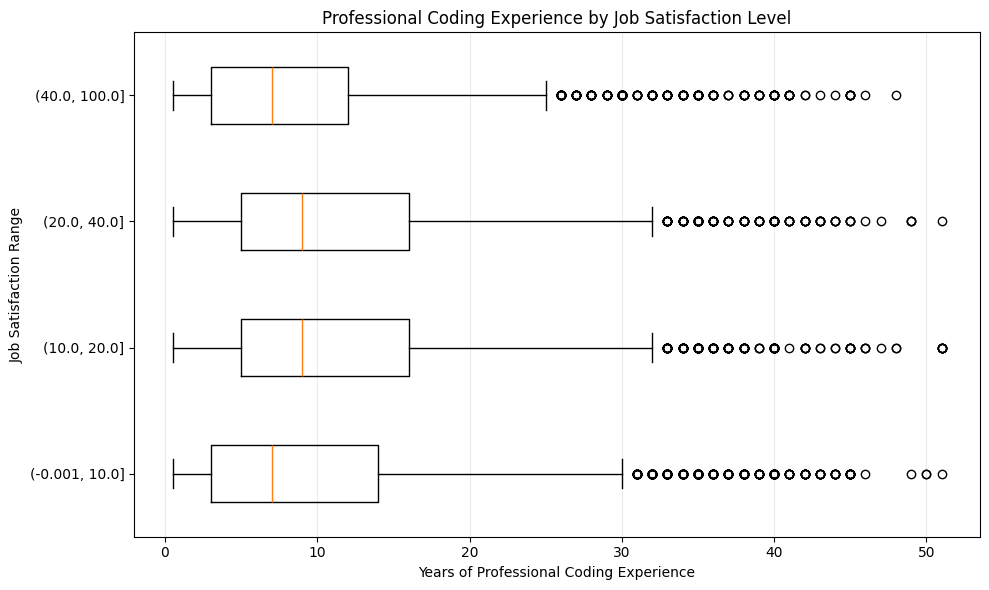

In [30]:
levels = sat_summary.index.tolist()

box_data = [
    experience_sat.loc[
        experience_sat["SatisfactionLevel"] == level,
        "YearsCodeProNumeric"
    ].values
    for level in levels
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    box_data,
    tick_labels=[str(level) for level in levels],
    vert=False,
    showfliers=True
)

plt.title(
    "Professional Coding Experience by Job Satisfaction Level"
)
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Job Satisfaction Range")

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

Examine the distribution of professional coding years by job satisfaction levels.


### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [31]:
conn.close()

### Analysis – Professional Coding Experience by Job Satisfaction Level

The box plots compare the distribution of `YearsCodePro` across four ranges of `JobSatPoints_6`.

The median professional coding experience is relatively similar across all satisfaction groups, generally remaining around the **7–10 year range**. The middle 50% of respondents also shows substantial overlap between groups, indicating that professional experience is distributed in a broadly similar way regardless of the `JobSatPoints_6` range.

The groups between **10 and 40 points** show slightly higher median experience and somewhat wider interquartile ranges than the lowest and highest satisfaction groups. However, these differences are modest and the boxes overlap considerably.

All groups contain numerous high-experience outliers, with some respondents reporting more than **40–50 years of professional coding experience**. These observations represent experienced professionals who fall well beyond the typical range within their respective satisfaction groups.

Overall, the visualization does **not show a strong or clearly increasing relationship between professional coding experience and `JobSatPoints_6`**. Respondents with both lower and higher satisfaction-point values can have similar levels of professional experience.

This suggests that years of professional coding experience alone are unlikely to explain differences in this job-satisfaction component. Other factors such as compensation, role, workload, work environment, career progression, or employment conditions may have a stronger influence.

It is also important to note that the satisfaction groups were created from the observed ranges of `JobSatPoints_6`. Therefore, the labels represent statistical intervals of this variable rather than predefined qualitative satisfaction categories.

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.
